In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import gc
from matplotlib.ticker import MaxNLocator
import warnings # Recomendado para ignorar avisos de plotagem

# 1. Configurações de exibição do Pandas (para facilitar o Sanity Check)
pd.set_option('display.max_columns', None)  # Ver todas as colunas
pd.set_option('display.float_format', '{:.4f}'.format) # Evita notação científica em g e RPM

# 2. Configurações Globais do Seaborn/Matplotlib
sns.set_theme(style="whitegrid") # Define um estilo limpo e profissional
plt.rcParams['figure.dpi'] = 100 # Melhora a resolução dos gráficos no VS Code
warnings.filterwarnings('ignore', category=UserWarning) # Oculta avisos de fontes/memória do Matplotlib

# 3. Definição de Paleta de Cores (Opcional, mas dá identidade ao projeto)
PALETA_VIB = ["#1f77b4", "#ff7f0e", "#d62728"] # Azul, Laranja, Vermelho
sns.set_palette(PALETA_VIB)

print("Ambiente configurado com sucesso!")

Ambiente configurado com sucesso!


In [2]:
# Definir experimento e caminhos
exp = 'B05'
projeto_root = Path.cwd().parent
arquivo_processado = projeto_root / 'data' / 'processed_data' / f"dataset_processado_{exp}_64kHz.parquet"

# Carregar dados
df = pd.read_parquet(arquivo_processado)

# Sanity Check: Ver as primeiras linhas e informações básicas
print(df.info())
display(df.head())

# Criação de variáveis temporais (Transformação)
df['Tempo_Decorrido_s'] = df['Rul_s'].max() - df['Rul_s']
df['Tempo_Decorrido_h'] = df['Tempo_Decorrido_s'] / 3600.0

<class 'pandas.DataFrame'>
RangeIndex: 58572800 entries, 0 to 58572799
Data columns (total 12 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Rul_s          float64
 1   setDynLoad_N   float64
 2   setStatLoad_N  float64
 3   setSpeed_rpm   float64
 4   peakDynLoad_N  float64
 5   StatLoad_N     float64
 6   Speed_rpm      float64
 7   TempT1_C       float64
 8   TempT2_C       float64
 9   RoomTemp_C     float64
 10  AccelA_g       float64
 11  AccelC_g       float64
dtypes: float64(12)
memory usage: 5.2 GB
None


,Rul_s,setDynLoad_N,setStatLoad_N,setSpeed_rpm,peakDynLoad_N,StatLoad_N,Speed_rpm,TempT1_C,TempT2_C,RoomTemp_C,AccelA_g,AccelC_g
0,10398.6000,0.0000,2500.0000,750.0000,27.4361,2491.6922,750.6546,20.9702,20.8696,20.9257,0.0814,-0.0688
1,10398.6000,0.0000,2500.0000,750.0000,27.4361,2491.6922,750.6546,20.9702,20.8696,20.9257,0.1109,-0.0945
2,10398.6000,0.0000,2500.0000,750.0000,27.4361,2491.6922,750.6546,20.9702,20.8696,20.9257,0.1131,-0.0749
3,10398.5999,0.0000,2500.0000,750.0000,27.4361,2491.6922,750.6546,20.9702,20.8696,20.9257,0.1239,-0.0928
4,10398.5999,0.0000,2500.0000,750.0000,27.4361,2491.6922,750.6546,20.9702,20.8696,20.9257,0.1339,-0.0775


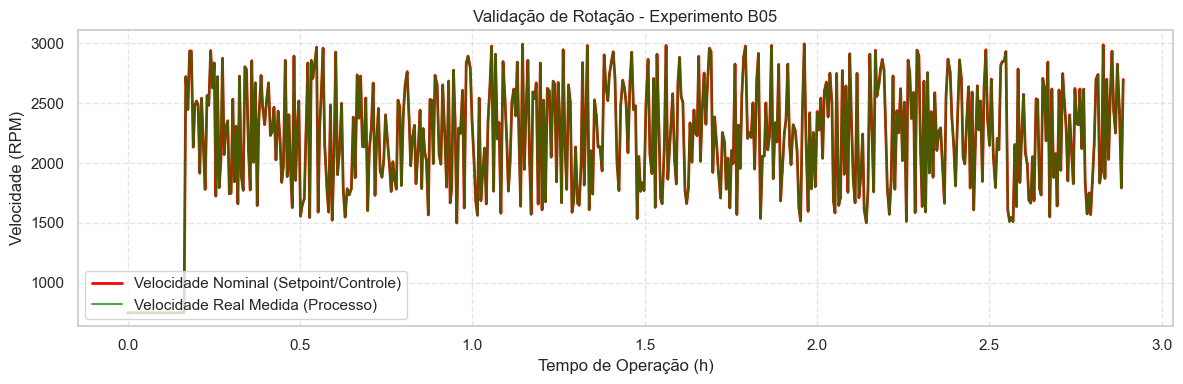

In [3]:
# 3.1 Avaliação das Variáveis de Controle vs. Processo (Velocidade)
plt.figure(figsize=(12, 4))
plt.plot(df['Tempo_Decorrido_h'].iloc[::100], df['setSpeed_rpm'].iloc[::100], label='Velocidade Nominal (Setpoint/Controle)', color='red', linewidth=2)
plt.plot(df['Tempo_Decorrido_h'].iloc[::100], df['Speed_rpm'].iloc[::100], label='Velocidade Real Medida (Processo)', color='green', alpha=0.7)
plt.title(f'Validação de Rotação - Experimento {exp}')
plt.xlabel('Tempo de Operação (h)')
plt.ylabel('Velocidade (RPM)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

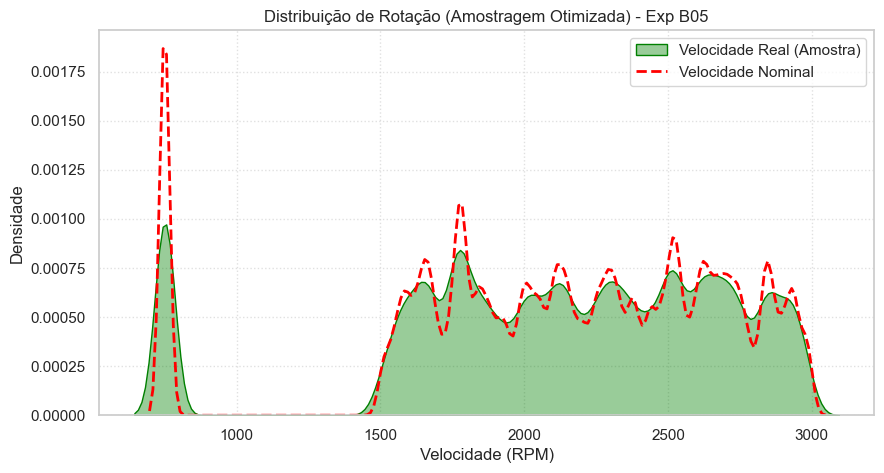

4249

In [5]:
# --- 3.1.2 Análise de Distribuição de Velocidade (Versão de Alta Performance) ---

plt.figure(figsize=(10, 5))

# Criamos uma amostra aleatória para o gráfico. 
# 100.000 pontos são mais que suficientes para uma curva de densidade perfeita.
df_sample = df.sample(n=min(100000, len(df)), random_state=42)

# Plot da Velocidade Real usando a AMOSTRA
sns.kdeplot(
    data=df_sample, 
    x='Speed_rpm', 
    fill=True, 
    color="green", 
    label='Velocidade Real (Amostra)', 
    bw_adjust=0.6,
    alpha=0.4
)

# Plot da Velocidade Nominal
# Como o setpoint costuma ter poucos valores únicos, podemos usar o df original ou a amostra
sns.kdeplot(
    data=df_sample, 
    x='setSpeed_rpm', 
    color="red", 
    linestyle="--", 
    linewidth=2,
    label='Velocidade Nominal',
    bw_adjust=0.3
)

plt.title(f'Distribuição de Rotação (Amostragem Otimizada) - Exp {exp}')
plt.xlabel('Velocidade (RPM)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Limpeza da amostra da memória logo após o uso
del df_sample
gc.collect()

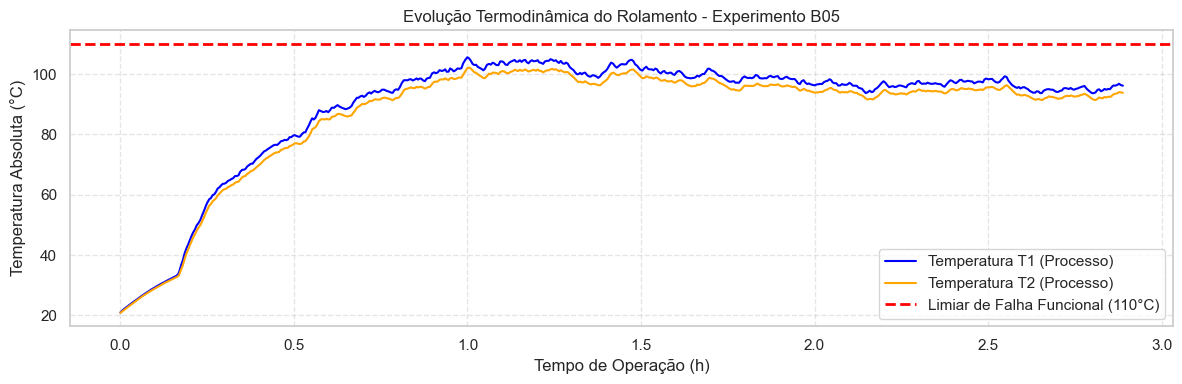

In [6]:
# 3.2 Avaliação Termodinâmica (Temperaturas de Processo)
plt.figure(figsize=(12, 4))
plt.plot(df['Tempo_Decorrido_h'].iloc[::64000], df['TempT1_C'].iloc[::64000], label='Temperatura T1 (Processo)', color='blue')
plt.plot(df['Tempo_Decorrido_h'].iloc[::64000], df['TempT2_C'].iloc[::64000], label='Temperatura T2 (Processo)', color='orange')
plt.axhline(y=110, color='red', linestyle='--', linewidth=2, label='Limiar de Falha Funcional (110°C)')
plt.title(f'Evolução Termodinâmica do Rolamento - Experimento {exp}')
plt.xlabel('Tempo de Operação (h)')
plt.ylabel('Temperatura Absoluta (°C)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

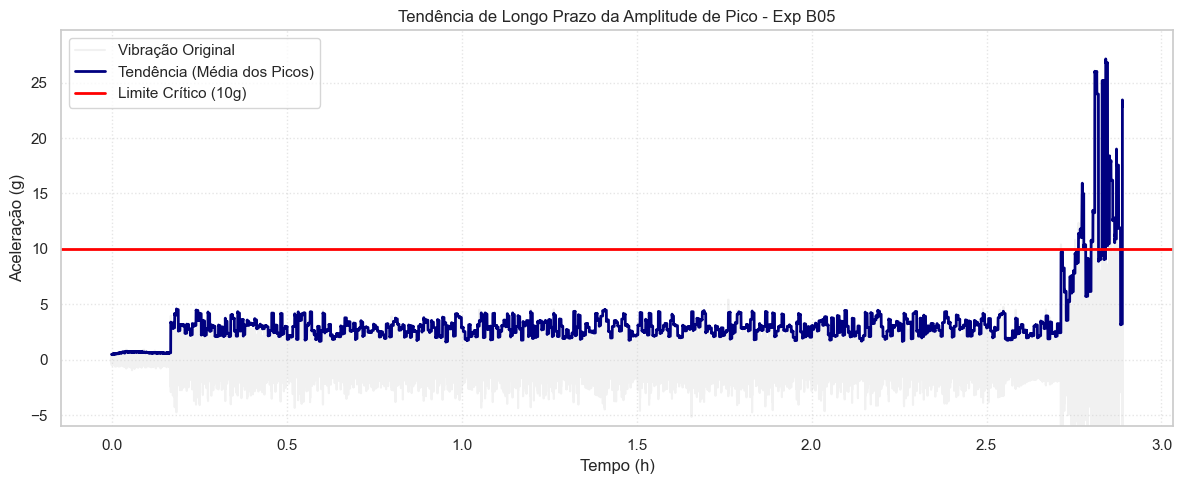

In [8]:
# --- 3.3 Avaliação Cinemática: Média Móvel dos Picos ---

# 1. Passo inicial: Valor Absoluto (Magnitude)
df['abs_AccelA_g'] = df['AccelA_g'].abs()

# 2. Passo intermediário: Extrair os Picos (Envelope)
# Janela curta (ex: 0.05s = 3200 pts) para capturar a amplitude real
df['AccelA_Peak'] = df['abs_AccelA_g'].rolling(window=3200).max(engine='cython')

# 3. Passo final: Média Móvel sobre os Picos (Tendência da Amplitude)
# Janela de suavização (ex: 1s = 64000 pts)
df['AccelA_Trend'] = df['AccelA_Peak'].rolling(window=64000).mean(engine='cython')

# --- Plotagem ---
plt.figure(figsize=(12, 5))

# Sinal Bruto (Original em cinza)
plt.plot(df['Tempo_Decorrido_h'].iloc[::100], df['AccelA_g'].iloc[::100], 
         color='lightgray', alpha=0.3, label='Vibração Original')

# Média Móvel dos Picos (A "Linha Azul" que você desejava)
plt.plot(df['Tempo_Decorrido_h'].iloc[::100], df['AccelA_Trend'].iloc[::100], 
         color='navy', linewidth=2, label='Tendência (Média dos Picos)')

# Limites e Ajuste de Eixo
plt.axhline(y=10, color='red', linestyle='-', linewidth=2, label='Limite Crítico (10g)')
plt.ylim(bottom=-6) # Atendendo ao seu pedido do eixo Y começar em -6

plt.title(f'Tendência de Longo Prazo da Amplitude de Pico - Exp {exp}')
plt.xlabel('Tempo (h)')
plt.ylabel('Aceleração (g)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

Processando intervalos temporais macroscopicamente...


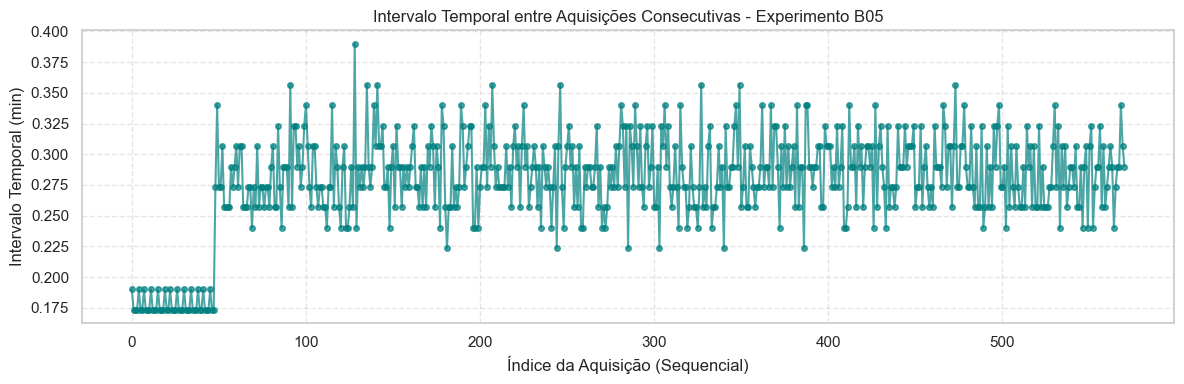

In [9]:
# 3.4 Intervalo Temporal entre Aquisições Consecutivas (Time Gap com Etiquetas)
print("Processando intervalos temporais macroscopicamente...")
delta_s = df['Tempo_Decorrido_s'].diff().fillna(0)

# Filtragem Analítica: saltos > 1.0s indicam o intervalo entre os chunks de 1.6s
df_gaps = df[delta_s > 1.0].copy()
df_gaps['delta_min'] = delta_s[delta_s > 1.0] / 60.0

# Formatação da etiqueta em MM:SS
df_gaps['delta_mmss'] = df_gaps['delta_min'].apply(
    lambda x: f"{int(x * 60) // 60:02d}:{int(x * 60) % 60:02d}"
)

plt.figure(figsize=(12, 4))
medicoes_idx = np.arange(len(df_gaps))

plt.plot(medicoes_idx, df_gaps['delta_min'], marker='o', linestyle='-', markersize=4, color='teal', alpha=0.7)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# Inserção de Rótulos (Labels) apenas para paradas > 1 minuto
for idx, value, label in zip(medicoes_idx, df_gaps['delta_min'], df_gaps['delta_mmss']):
    if value > 1.0:
        plt.text(idx, value + 0.1, label, fontsize=9, ha='center', va='bottom', color='darkred', weight='bold')

plt.xlabel('Índice da Aquisição (Sequencial)')
plt.ylabel('Intervalo Temporal (min)')
plt.title(f'Intervalo Temporal entre Aquisições Consecutivas - Experimento {exp}')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# --- 4. Liberação Explícita e Segura de Memória ---

# Lista das variáveis que queremos limpar
vars_para_limpar = ['df', 'df_gaps', 'delta_s', 'medicoes_idx', 'df_dist']

for var in vars_para_limpar:
    if var in locals() or var in globals():
        exec(f"del {var}")

# Força o Garbage Collector a agir
gc.collect()

print("RAM limpa...")

RAM limpa...
